In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("postings.csv.zip")

In [4]:
df

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,NaN,...,NaN,1.713571e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,94595.0,6013.0
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,NaN,NaN,United States,1124131.0,3.0,NaN,...,NaN,1.713572e+12,www.pinterestcareers.com,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,NaN,NaN,"Spokane, WA",90552133.0,3.0,NaN,...,NaN,1.713572e+12,epsoperations.bamboohr.com,0,FULL_TIME,NaN,NaN,NaN,99201.0,53063.0
123847,3906267195,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,NaN,NaN,"Texas, United States",2793699.0,4.0,NaN,...,NaN,1.713573e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN


In [6]:
pd.to_datetime(df["listed_time"], unit="s")

0           Sunday
1         Saturday
2         Saturday
3         Thursday
4           Sunday
            ...   
123844     Tuesday
123845    Saturday
123846      Monday
123847    Thursday
123848    Thursday
Name: listed_time, Length: 123849, dtype: str

In [ ]:
# The problem statement:
#Between 2023_2024,the 124k job advertisements were posted on LinkedIn in the United States; 
#69% required an intermediate level of experience, while only 31% were suitable for recent graduates.
#this disparity results in  job seekers spending time applying for positions for which they do not qualify.

In [82]:
total_of_postings=len(df)
total_of_postings

123849

In [83]:
top=15

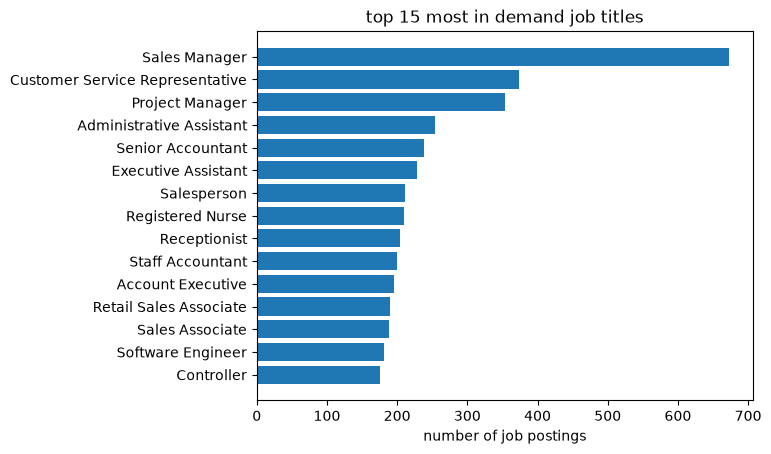

In [65]:
#q1:transforming the data into a clear picture of the most in demand jobs in the market.
total_of_postings=len(df)
total_of_postings
top=15
demand=(df["title"].value_counts().head(top).reset_index(name="postings"))
fig,axes=plt.subplots()
demand_sorted=demand.iloc[::-1]
axes.barh(demand_sorted["title"],demand_sorted["postings"])
axes.set_xlabel("number of job postings")
axes.set_title("top 15 most in demand job titles")
plt.show()


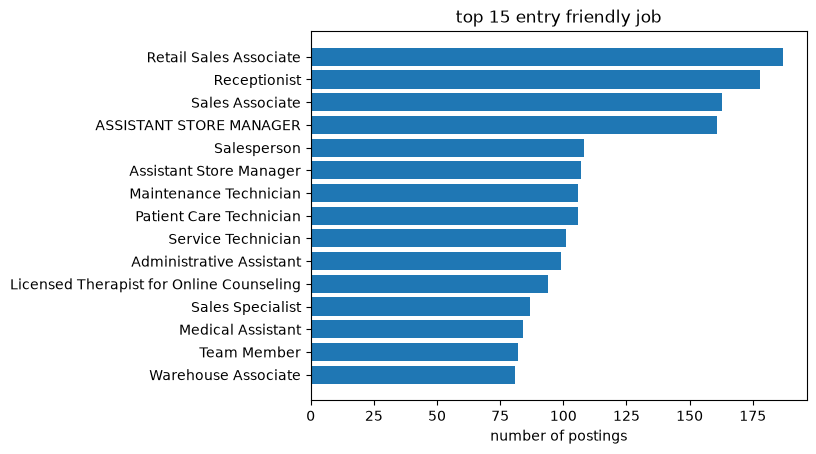

In [47]:
#q2:which jobs accept beginners: 
entry_levels=["Entry level","Internship"]
is_entry=df["formatted_experience_level"].isin(entry_levels)
entry_df=df[is_entry]
total_of_postings=len(df)
total_entry=len(entry_df)
top_by_count=(entry_df["title"].value_counts().head(top).reset_index(name="postings"))
fig, axes=plt.subplots()
data=top_by_count.iloc[::-1]
axes.barh(data["title"],data["postings"])
axes.set_xlabel("number of postings")
axes.set_title("top 15 entry friendly job")
plt.show()


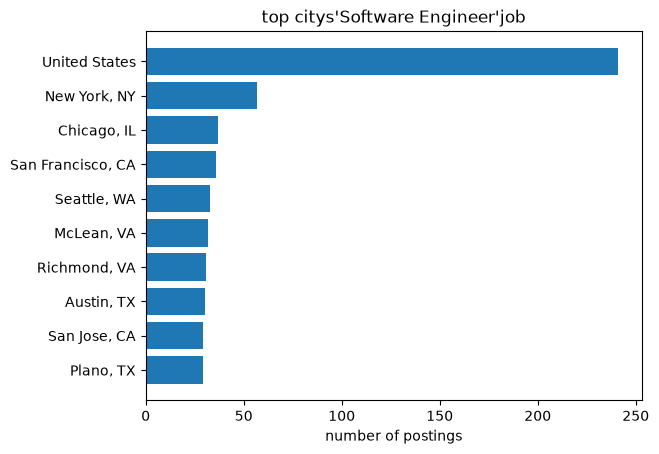

In [46]:
#q3:solving the distribution challenge for job seekers willing to relocate
#example1
specialization="Software Engineer"
matche=df[df["title"].str.contains(specialization,case=False,na=False)]
top_citys=(matche["location"].value_counts().head(10).reset_index(name="postings"))
fig,axes=plt.subplots()
data=top_citys.iloc[::-1]
axes.barh(data["location"],data["postings"])
axes.set_xlabel("number of postings")
axes.set_title(f"top citys'{specialization}'job")
plt.show()

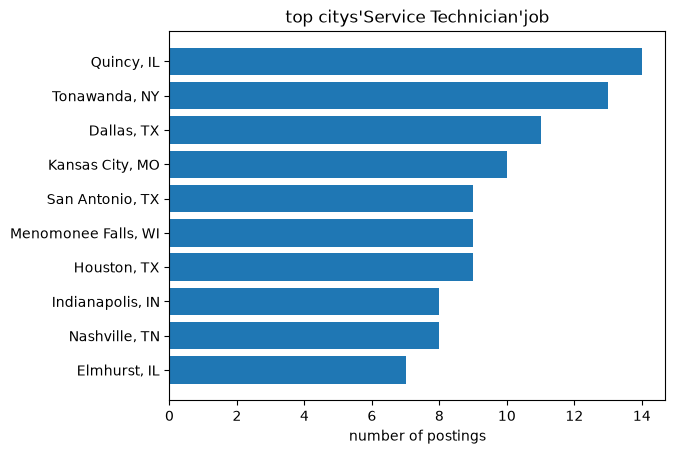

In [45]:
#q3:solving the distribution challenge for job seekers willing to relocate
#example2
specialization="Service Technician"
matche=df[df["title"].str.contains(specialization,case=False,na=False)]
top_citys=(matche["location"].value_counts().head(10).reset_index(name="postings"))
fig,axes=plt.subplots()
data=top_citys.iloc[::-1]
axes.barh(data["location"],data["postings"])
axes.set_xlabel("number of postings")
axes.set_title(f"top citys'{specialization}'job")
plt.show()

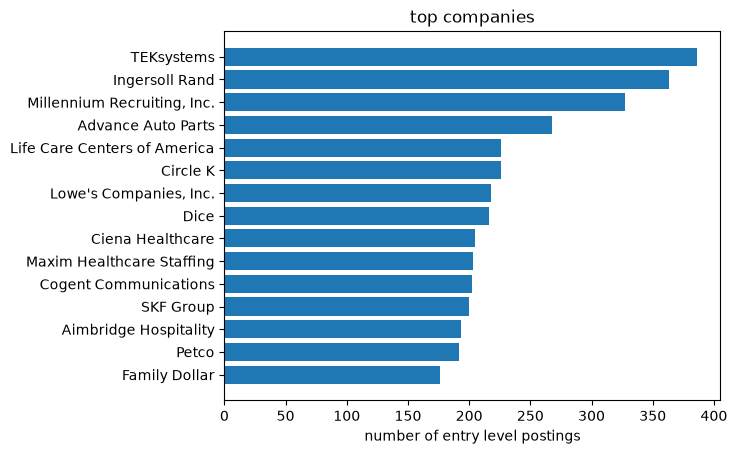

In [42]:
#q4:Which companies hire the largest number of entry-level employees
entry_levels=["Entry level","Internship"]
is_entry=df["formatted_experience_level"].isin(entry_levels)
entry_df=df[is_entry]
total_of_postings=len(df)
total_entry=len(entry_df)
top_by_companies=(entry_df["company_name"].value_counts().head(top).reset_index(name="postings"))
fig, axes=plt.subplots()
data=top_by_companies.iloc[::-1]
axes.barh(data["company_name"],data["postings"])
axes.set_xlabel("number of entry level postings")
axes.set_title("top companies")
plt.show()

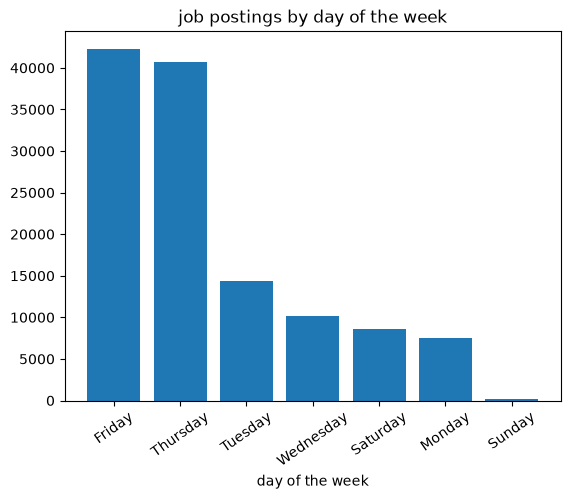

In [64]:
#q5:on which day of the week are the highest number of jobs posted?
df["listed_date"]=pd.to_datetime(df["listed_time"], unit="ms")
order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
postings_day=df["listed_date"].dt.day_name().value_counts().reset_index(name="order")
fig,axes=plt.subplots()
plt.xticks(rotation=35)
axes.bar(postings_day["listed_date"], postings_day["order"])
axes.set_xlabel("day of the week")
axes.set_title("job postings by day of the week")
plt.show()

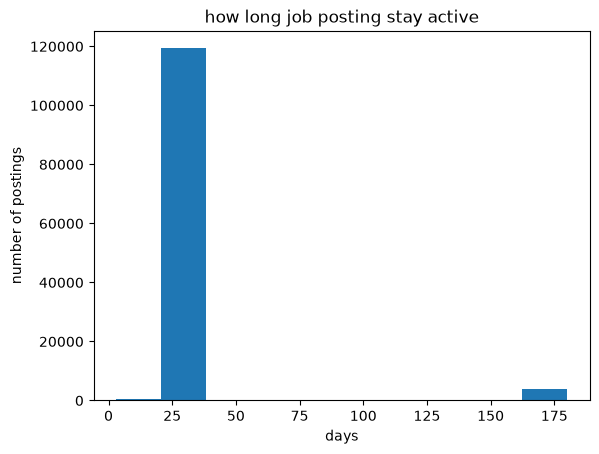

In [41]:
#q6:How many days does the job posting remain active before it expires
df["listed_date"]=pd.to_datetime(df["listed_time"],unit="ms")
df["expiry_date"]=pd.to_datetime(df["expiry"],unit="ms")
df["duration_days"]=(df["expiry_date"]-df["listed_date"]).dt.days
fig,axes=plt.subplots()
axes.hist(df["duration_days"])
axes.set_xlabel("days")
axes.set_ylabel("number of postings")
axes.set_title("how long job posting stay active")
plt.show()

In [13]:
#q7:What is the expected salary for each experience level (entry-level, mid-level, manager, executive...)?

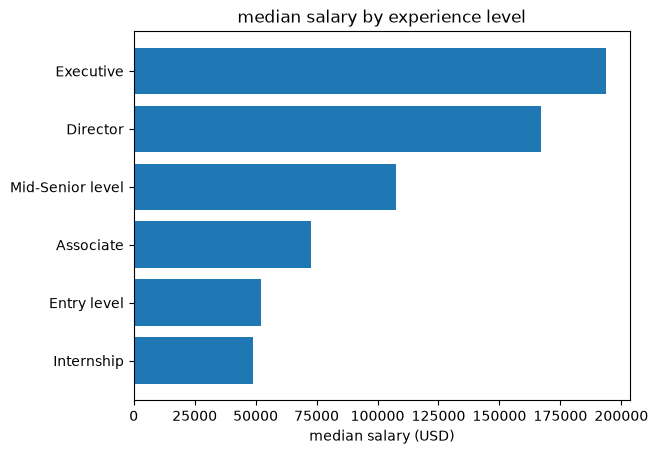

In [54]:
salary=df[df["normalized_salary"].notna()]
median_salary=salary.groupby("formatted_experience_level")["normalized_salary"].median().sort_values()
fig, axes=plt.subplots()
axes.barh(median_salary.index, median_salary.values)
axes.set_xlabel("median salary (USD)")
axes.set_title("median salary by experience level")
plt.show()